--- ANALYTICS SUMMARY ---
Most Popular Posting Hour: 15:00

Top Users:
User
Eve      19
Neha     18
Heidi    17
David    16
Sam      16
Name: count, dtype: int64


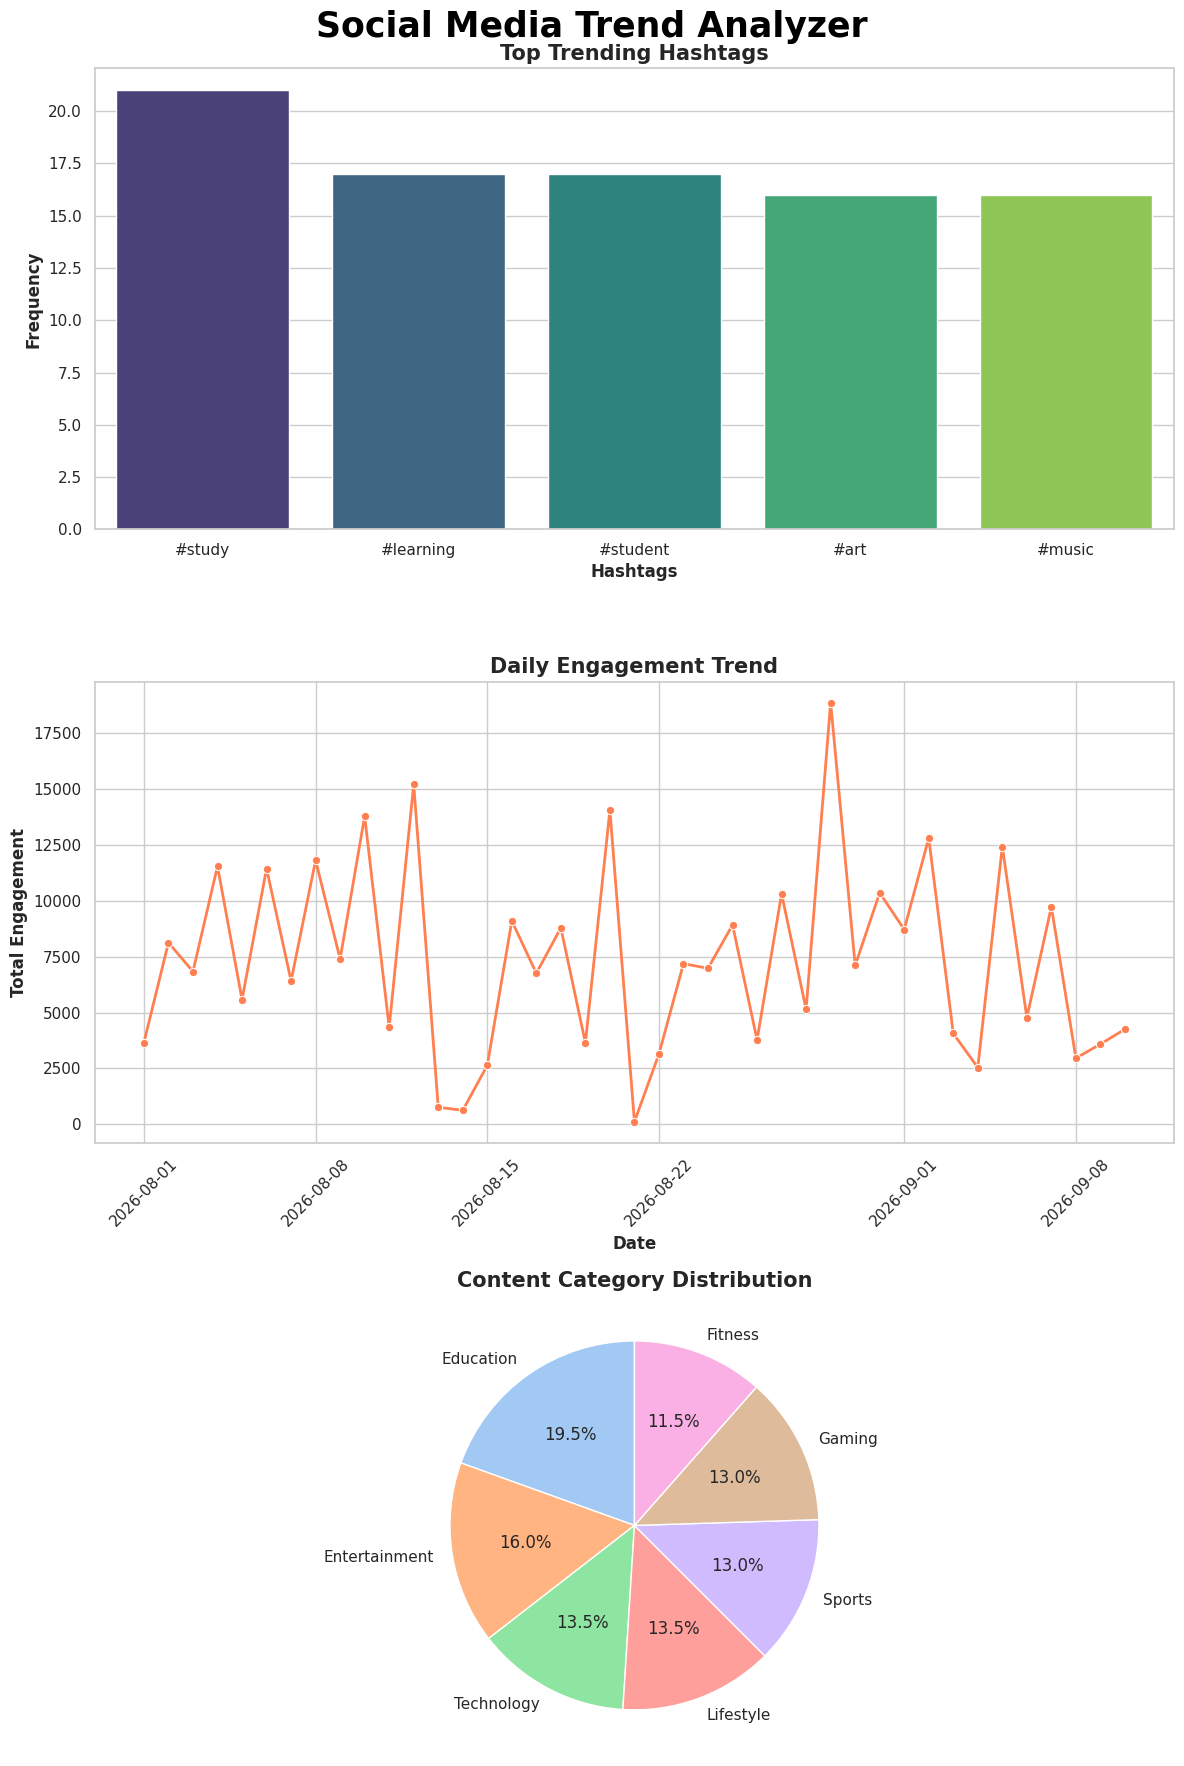


Report successfully exported to 'social_media_analytics_report.csv'


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Read Data
df = pd.read_csv('social_media_data.csv') 

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Calculate Engagement
df['Total_Engagement'] = df['Likes'] + df['Comments'] + df['Shares']

# 3. Identify Top Hashtags
# Split the space-separated strings, explode into separate rows, and count
hashtags = df['Hashtags'].str.split(' ').explode()
top_hashtags = hashtags.value_counts().head(5)

# 4. Analyze Active Users & Posting Times
active_users = df['User'].value_counts().head(5)
df['Hour'] = df['Timestamp'].dt.hour
popular_time = df['Hour'].mode()[0]

print("--- ANALYTICS SUMMARY ---")
print(f"Most Popular Posting Hour: {popular_time}:00")
print(f"\nTop Users:\n{active_users}")

# 5. Generate Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3,1, figsize=(12, 18))
fig.suptitle("Social Media Trend Analyzer",fontweight="bold",color = "black",fontsize=25)

# Chart A: Top Hashtags Chart (Bar)
sns.barplot(x=top_hashtags.index, y=top_hashtags.values, ax=axes[0], palette="viridis",hue =top_hashtags.index)
axes[0].set_title('Top Trending Hashtags',fontweight="bold",fontsize=15)
axes[0].set_xlabel('Hashtags',fontweight="bold")
axes[0].set_ylabel('Frequency',fontweight="bold")

# Chart B: Daily Engagement Trend (Line)
daily_eng = df.groupby(df['Timestamp'].dt.date)['Total_Engagement'].sum()
sns.lineplot(x=daily_eng.index, y=daily_eng.values, ax=axes[1], marker="o", color="coral", linewidth=2)
axes[1].set_title('Daily Engagement Trend',fontweight="bold",fontsize=15)
axes[1].set_xlabel('Date',fontweight="bold")
axes[1].set_ylabel('Total Engagement',fontweight="bold")
axes[1].tick_params(axis='x', rotation=45)

# Chart C: Content Category Distribution (Pie)
category_dist = df['Category'].value_counts()
axes[2].pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[2].set_title('Content Category Distribution',fontweight="bold",fontsize=15)

plt.tight_layout()
plt.show()

# 6. Export Analytics Report
analytics_df = pd.DataFrame({
    'Top_Hashtags': top_hashtags.index,
    'Hashtag_Count': top_hashtags.values
})
analytics_df.to_csv('social_media_analytics_report.csv', index=False)
print("\nReport successfully exported to 'social_media_analytics_report.csv'")